In [1]:
from datetime import datetime
import numpy as np

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Session

from qaoa_training_pipeline.training import TQATrainer
from qaoa_training_pipeline.utils.graph_utils import solve_max_cut, graph_to_operator, load_graph
from qaoa_training_pipeline.utils.problem_classes import MaxCut
from qaoa_training_pipeline.utils.data_utils import load_input

from qaoa_parameter_setting.transpilation.make_qaoa_circuits import make_qaoa_circuit

In [2]:
service = QiskitRuntimeService(instance="...")
backend = service.backend("ibm_boston")

management.get:WARNING:2025-12-15 21:03:24,008: Loading default saved account


In [3]:
file_name = "instances/line_to_full/000_100nodes_2swap_layers.json"

circuit, swaps = make_qaoa_circuit(
    file_name,
    "maxcut",
    reps=4,
    backend=backend,
)

In [4]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(β[2]), ParameterVectorElement(β[3]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1]), ParameterVectorElement(γ[2]), ParameterVectorElement(γ[3])])

In [5]:
circuit.count_ops(), circuit.depth(lambda x: len(x.qubits) > 1)

(OrderedDict([('rz', 4944), ('sx', 4052), ('cz', 1980), ('measure', 100)]), 40)

In [6]:
input_data = load_input(file_name)
cost_op = MaxCut().cost_operator(input_data)

In [7]:
import time

class Evaluator:

    def __init__(self, cost_op):
        """Initialize the class."""

        self._cost_op = cost_op
        self._reals = []
        self._ainds = []
        start = time.time()
        for pauli in self._cost_op:
            indices = tuple([idx for idx, val in enumerate(pauli.paulis[0].z) if val])
            self._ainds.append(indices)
            self._reals.append(np.real(pauli.coeffs[0]))

        self._init_time = time.time() - start

    @property
    def cost_op(self):
        return self._cost_op

    def energy(self, sample):

        sample = [True if val == "1" else False for val in sample[::-1]]
        
        energy = 0
        for aidx, val in enumerate(self._reals):
            if sample[self._ainds[aidx][0]] == sample[self._ainds[aidx][1]]:
                energy += val
            else:
                energy -= val
        
        return energy

    def cvar(self, energies, alpha=1.00):
        sorted_energies = sorted(energies)
        end_idx = max(int(alpha * len(energies)), 1)
        
        return float(np.sum(sorted_energies[0:end_idx]) / end_idx)

### CPLEX solution

Note that below on the hardware we minimized the energy. But the true Maxcut would have corresponded to a maximization. To compensate for this we flip the sign of the weights of the edges that we feed to CPLEX. We can see that the energy of the maxcut problem, converted to an Ising Hamiltonian, that CPLEX solves corresponds to the one that we optimized.

In [263]:
from qiskit_addon_opt_mapper.solvers import CplexSolver
from qiskit_addon_opt_mapper.applications import Maxcut
from qiskit_addon_opt_mapper.translators import to_ising
from qiskit_addon_opt_mapper.problems.optimization_objective import ObjSense
import networkx as nx

In [212]:
ld_graph = load_graph(file_name)

In [242]:
new_graph = nx.Graph()
for e in ld_graph.edges(data=True):
    new_graph.add_weighted_edges_from([(e[0], e[1], -e[2]["weight"])])

In [259]:
mc = Maxcut(new_graph).to_quadratic_program()
cplex_res = CplexSolver().solve(mc)

In [266]:
cplex_res.fval

51.0

In [264]:
min_cut = Maxcut(new_graph).to_quadratic_program()
min_cut.objective._sense = ObjSense.MINIMIZE
cplex_res_min = CplexSolver().solve(min_cut)

In [265]:
cplex_res_min.fval

-78.0

In [260]:
add_on_op, offset = to_ising(mc)
cplex_evaluator = Evaluator(add_on_op)

In [261]:
cost_op == add_on_op

True

In [267]:
cplex_opt = "".join(str(int(bit)) for bit in cplex_res.x)[::-1]
cplex_min = "".join(str(int(bit)) for bit in cplex_res_min.x)[::-1]
cplex_evaluator.energy(cplex_opt), cplex_evaluator.energy(cplex_min)

(np.float64(-65.0), np.float64(64.0))

In [268]:
evaluator.energy(cplex_opt), evaluator.energy(cplex_min)

(np.float64(-65.0), np.float64(64.0))

In [269]:
best_val, worst_val = float(evaluator.energy(cplex_opt)), float(evaluator.energy(cplex_min))

### Hardware optimization

In [8]:
evaluator = Evaluator(cost_op)
evaluator._init_time

0.0065267086029052734

In [9]:
len(cost_op)

198

In [10]:
start = time.time()
vals = np.random.uniform(0, 1, 20000)
np.sum(sorted(vals)[0:10000])
time.time() - start

0.005997419357299805

In [11]:
sample = "0" * 100
start = time.time()
for _ in range(20000):
    evaluator.energy(sample)

ttime = time.time() - start
print(ttime)

0.6985528469085693


In [12]:
tqa_res = TQATrainer(initial_dt=[0.5, 0.5]).train(cost_op, reps=4)
tqa_res["optimized_qaoa_angles"]

[0.5, 0.375, 0.25, 0.125, 0.125, 0.25, 0.375, 0.5]

In [13]:
max_rep = backend.rep_delay_range[1]
min_rep = backend.rep_delay_range[0]
max_rep*1e6, min_rep*1e6

(500.0, 20.0)

In [14]:
from qiskit import QuantumCircuit, transpile

from scipy.optimize import minimize

In [15]:
evaluator = Evaluator(cost_op)
shots = 20000

x0 = tqa_res["optimized_qaoa_angles"]
delay = 40e-6

with Session(backend=backend) as session:
    print("Session ID:", session.session_id)
    sampler = SamplerV2(mode=session, options={"execution": {"rep_delay": delay}})

    # Add a dummy circuit here
    dummy_qc = QuantumCircuit(1)
    dummy_qc.measure_all()
    dummy_qc = transpile(dummy_qc, backend)
    dummy_job = sampler.run([dummy_qc], shots=10)
    dummy_job.result()

    # Now do the real thing
    history = []
    
    def objective(x):
        start = time.time()
        assigned_circuit = circuit.assign_parameters(x, inplace=False)
        sampler_job = sampler.run([assigned_circuit], shots=shots)
        sampler_result = sampler_job.result()
        counts = sampler_result[0].data.c.get_counts()
        sampling_time = time.time() - start
        start = time.time()
        energies = []
        for sample, count in counts.items():
            energies += count * [evaluator.energy(sample)]

        total_energy = evaluator.cvar(energies, 0.05)
        
        classical_post_process_time = time.time() - start
        history.append((sampling_time, total_energy, x.tolist(), counts, classical_post_process_time))

        print(history[-1][0], history[-1][1])
        
        return total_energy
    
    result = minimize(
        objective, x0=x0, method="COBYLA", options={"maxiter": 100, "rhobeg": 0.1}
    )

Session ID: eb93807d-9671-4949-bfee-58d3022af562
14.623584270477295 15.935
8.494765996932983 15.385
8.296852350234985 13.651
8.611189365386963 14.134
7.1743597984313965 16.395
8.515843868255615 10.817
7.445300579071045 13.707
7.898512840270996 12.031
7.9834535121917725 10.012
7.740981101989746 0.664
7.638840913772583 -15.226
8.53711986541748 -23.245
7.831079483032227 -21.766
8.168497562408447 -22.795
7.9832470417022705 -28.587
7.920842170715332 -29.267
8.131051301956177 -28.426
7.373402833938599 -28.491
8.20947265625 -35.601
8.453138589859009 -37.694
9.311464071273804 -40.516
8.199013471603394 -40.035
8.857001304626465 -39.882
8.027962923049927 -38.18
7.497731924057007 -40.96
7.569698810577393 -41.349
7.65057897567749 -41.378
8.507547378540039 -42.097
8.065712451934814 -42.406
7.742903709411621 -41.177
7.584909439086914 -41.55
7.869900941848755 -43.271
7.839508295059204 -41.498
7.8531036376953125 -43.521
7.552490711212158 -41.373
7.926763296127319 -43.63
7.756450891494751 -42.772
8.143

In [84]:
import json

In [18]:
with open("data/hardware/variational/20251215_eb93807d-9671-4949-bfee-58d3022af562_000_100nodes_2swap_layers.json", "w") as fout:
    json.dump(history, fout, indent=4)

## Load saved data and plot it

In [93]:
from collections import defaultdict
import matplotlib.pyplot as plt

In [23]:
with open("data/hardware/variational/20251215_eb93807d-9671-4949-bfee-58d3022af562_000_100nodes_2swap_layers.json", "r") as fin:
    loaded_history = json.load(fin)

In [101]:
from qaoa_training_pipeline.visualization.plotting import plot_cdf

In [274]:
assert set(loaded_history[-1][3].values()) == set({1})
nshots = len(loaded_history[-1][3].values())

energies, uniform_es = defaultdict(int), defaultdict(int)
for sample, count in loaded_history[-1][3].items():
    val = (evaluator.energy(sample) - worst_val) / (best_val - worst_val)
    energies[val] += 1/nshots

uniform = np.random.choice([0, 1], (nshots, len(cost_op.paulis[0])))
for sample in uniform:
    val = (evaluator.energy("".join([str(bit) for bit in sample])) - worst_val) / (best_val - worst_val)
    uniform_es[val] += 1/nshots

In [290]:
max(energies.keys())

np.float64(0.9147286821705426)

Median time for 20000 samples from user perspective: 8.00 seconds


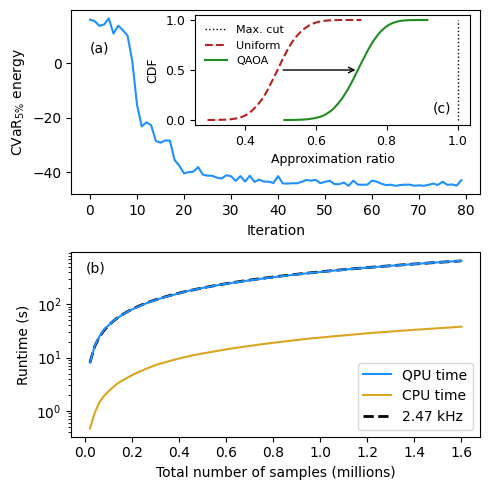

In [309]:
fig, axs = plt.subplots(2, 1, figsize=(5, 5))
axs[0].plot([hist[1] for hist in loaded_history], color="dodgerblue")
xsamples = np.cumsum([sum(hist[3].values()) for hist in loaded_history])/1e6

delta = np.median([hist[0] for hist in loaded_history])
print(f"Median time for {sum(loaded_history[0][3].values())} samples from user perspective: {delta:.2f} seconds")
cumulative_qpu = [delta]
for idx, hist in enumerate(loaded_history[1:]):
    t_qpu = hist[0]
    if t_qpu > 10 * delta:
        t_qpu = delta
    cumulative_qpu.append(t_qpu + cumulative_qpu[-1])

delta = np.median([hist[4] for hist in loaded_history])
cumulative_cpu = [delta]
for idx, hist in enumerate(loaded_history[1:]):
    t_cpu = hist[4]
    if t_cpu > 10 * delta:
        t_cpu = delta
    cumulative_cpu.append(t_cpu + cumulative_cpu[-1])

axs[1].plot(xsamples, cumulative_qpu, label="QPU time", color="dodgerblue")# to generate samples")
axs[1].plot(xsamples, cumulative_cpu, label="CPU time", color="goldenrod")# to process samples")
rate = 2.47e3
axs[1].plot(xsamples, 1e6*xsamples/rate, label=f"{rate/1e3} kHz", color="black", zorder=-10, lw=2, ls="--")# to process samples")
axs[1].legend()
axs[0].set_xlabel("Iteration")
axs[0].set_ylabel("CVaR$_{5\%}$ energy")
axs[1].set_xlabel("Total number of samples (millions)")
axs[1].set_ylabel("Runtime (s)"); #  without queuing
axs[1].set_yscale("log")
axs[0].text(0, 4.0, "(a)")
axs[1].text(0, 400, "(b)")

fig.tight_layout()

left, bottom, width, height = [0.4, 0.74, 0.55, 0.22] # Position and size
axi = fig.add_axes([left, bottom, width, height])
axi.vlines(1, 0, 1, color="k", ls=":", label="Max. cut", lw=1)
plot_cdf(uniform_es, axis=axi, fig=fig, color="firebrick", ls="--", label="Uniform")
plot_cdf(energies, axis=axi, fig=fig, color="forestgreen", label="QAOA")
axi.set_ylabel("CDF", fontsize=9)
axi.set_xlabel("Approximation ratio", fontsize=9)
axi.tick_params(axis='both', which='major', labelsize=9)
axi.legend(loc=2, fontsize=8, frameon=False)
axi.text(0.93, 0.08, "(c)")

axi.annotate(
    text='',  # No text, just the arrow
    xy=(0.72, 0.5),  # Arrow head position
    xytext=(0.5, 0.5),  # Arrow tail position
    arrowprops=dict(facecolor='red', arrowstyle='->', lw=1)
)
fig.savefig("20251215_hardware_convergence_example.pdf", bbox_inches="tight")

In [327]:
avg_qpu_time = np.average([val[0] for val in loaded_history])
std_qpu_time = np.std([val[0] for val in loaded_history])
print(f"The user wall-clock time to obtain the quantum samples is {avg_qpu_time:.1f} pm {std_qpu_time:.1f} seconds.")

The user wall-clock time to obtain the quantum samples is 8.2 pm 0.9 seconds.


In [305]:
def time_spent(job):

    # Your timestamps
    t1 = job.metrics()["timestamps"]["running"]
    t2 = job.metrics()["timestamps"]["finished"]
    
    # Parse them into datetime objects (strip the 'Z' and set tzinfo=UTC)
    fmt = "%Y-%m-%dT%H:%M:%S.%fZ"
    dt1 = datetime.strptime(t1, fmt)
    dt2 = datetime.strptime(t2, fmt)
    
    # Compute difference
    delta = dt2 - dt1
    return delta.total_seconds()


In [60]:
all_jobs = service.jobs(session_id="eb93807d-9671-4949-bfee-58d3022af562", limit=100)

In [306]:
job_times = []
for job in all_jobs:
    job_times.append(time_spent(job))

In [308]:
avg_job_time, std_job_time = np.average(job_times), np.std(job_times)
print(f"The completion time reported by the backend to obtain the quantum samples is {avg_job_time:.2f} pm {std_job_time:.2f} seconds.")

The completion time reported by the backend to obtain the quantum samples is 5.78 pm 0.51 seconds.


In [313]:
print(f"The total QPU runtime is {cumulative_qpu[-1]:.2f} seconds, i.e., {cumulative_qpu[-1]/60:.2f} minutes")

The total QPU runtime is 648.54 seconds, i.e., 10.81 minutes


In [316]:
print(f"The total CPU runtime is {cumulative_cpu[-1]:.2f} seconds, i.e., {cumulative_cpu[-1]/60:.2f} minutes")

The total CPU runtime is 37.92 seconds, i.e., 0.63 minutes


In [328]:
20000/8.2

2439.024390243903

In [323]:
cumulative_cpu[-1]/60 + cumulative_qpu[-1]/60

np.float64(11.440983349084854)

## Fidelity numbers

Median fidelity on IBM Boston 1.28e-3.

In [321]:
(1-1.28e-3)**(1980/2)

0.2813905545670037

In [322]:
1-1.28e-3

0.99872